In [1]:
# 不是最终版，看.py
import os
import sys
import shutil
import time
import random
import argparse
import torch
import torch.backends.cudnn as cudnn
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as dset
import torchvision.transforms as transforms
from utils_.utils import AverageMeter, RecorderMeter, time_string, convert_secs2time
from tensorboardX import SummaryWriter
import models
import copy
import numpy as np
from models.attack_model import Attack
from models.nomarlization_layer import Normalize_layer, noise_Normalize_layer
from numpy.random import RandomState
import copy
import csv

In [2]:
from argparse import Namespace
# 创建一个命名空间对象
args = Namespace()
args.dataset = 'cifar10'
args.adv_eval = False
args.data_path = '/home/xueqiong/CVPR_2019_PNI-master/data'
args.batch_size = 500
args.workers = 4
args.input_noise = False
args.learning_rate = 0.1
args.momentum = 0.9
args.decay = 0.0003
args.fine_tune = False
# -------------上面的基本上不用动，下面的要改
args.use_cuda = False
args.arch = 'dropout_resnet8'
args.adv_train = False
args.fix_noise_level = 0.1
args.ngpu = 1
args.manualSeed = 123
args.optimizer = 'SGD'
args.num_filters = 4

In [3]:
def print_log(print_string, log):
    print("{}".format(print_string))
    log.write('{}\n'.format(print_string))
    log.flush()

In [4]:
args.folder = "cifar10_dropout_resnet8_4_160_SGD_notadv"
args.resume_path = '/home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/{}'.format(args.folder)
args.save_path = os.path.join(args.resume_path, 'test')

# Init logger
if not os.path.isdir(args.save_path):
    os.makedirs(args.save_path)
log = open(os.path.join(args.save_path,
                        'log_seed_{}.txt'.format(args.manualSeed)), 'w')
if args.use_cuda == False:
    print_log('No GPU!', log)
    print_log('{},{}'.format(args.ngpu,torch.cuda.is_available()), log)
print_log('save path : {}'.format(args.save_path), log)
state = {k: v for k, v in args._get_kwargs()}
print_log(state, log)
print_log("Random Seed: {}".format(args.manualSeed), log)
print_log("python version : {}".format(
    sys.version.replace('\n', ' ')), log)
print_log("torch  version : {}".format(torch.__version__), log)
print_log("cudnn  version : {}".format(
    torch.backends.cudnn.version()), log)

# Init the tensorboard path and writer
tb_path = os.path.join(args.save_path, 'tb_log')
writer = SummaryWriter(tb_path)

No GPU!
1,True
save path : /home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/cifar10_dropout_resnet8_4_160_SGD_notadv/test
{'dataset': 'cifar10', 'adv_eval': False, 'data_path': '/home/xueqiong/CVPR_2019_PNI-master/data', 'batch_size': 500, 'workers': 4, 'input_noise': False, 'learning_rate': 0.1, 'momentum': 0.9, 'decay': 0.0003, 'fine_tune': False, 'use_cuda': False, 'arch': 'dropout_resnet8', 'adv_train': False, 'fix_noise_level': 0.1, 'ngpu': 1, 'manualSeed': 123, 'optimizer': 'SGD', 'num_filters': 4, 'folder': 'cifar10_dropout_resnet8_4_160_SGD_notadv', 'resume_path': '/home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/cifar10_dropout_resnet8_4_160_SGD_notadv', 'save_path': '/home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/cifar10_dropout_resnet8_4_160_SGD_notadv/test'}
Random Seed: 123
python version : 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:12:24) [GCC 11.2.0]
torch  version : 2.4.1+cu12

In [5]:
if args.dataset == 'cifar10':
    mean = [x / 255 for x in [125.3, 123.0, 113.9]]
    std = [x / 255 for x in [63.0, 62.1, 66.7]]
elif args.dataset == 'cifar100':
    mean = [x / 255 for x in [129.3, 124.1, 112.4]]
    std = [x / 255 for x in [68.2, 65.4, 70.4]]
elif args.dataset == 'svhn':
    mean = [0.5, 0.5, 0.5]
    std = [0.5, 0.5, 0.5]
elif args.dataset == 'mnist':
    mean = [0.5, 0.5, 0.5]
    std = [0.5, 0.5, 0.5]
elif args.dataset == 'imagenet':
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
else:
    assert False, "Unknow dataset : {}".format(args.dataset)

# Current data-preprocessing does not include the normalization
imagenet_train_transform = [
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()]
imagenet_test_transform = [
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()]

normal_train_transform = [
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor()]
normal_test_transform = [
    transforms.ToTensor()]

# if not performing the adversarial training or evalutaion, we append
# the normalization back to the preprocessing
if not (args.adv_train or args.adv_eval):
    imagenet_train_transform.append(transforms.Normalize(mean, std))
    imagenet_test_transform.append(transforms.Normalize(mean, std))
    normal_train_transform.append(transforms.Normalize(mean, std))
    normal_test_transform.append(transforms.Normalize(mean, std))

if args.dataset == 'imagenet':
    train_transform = transforms.Compose(imagenet_train_transform)
    test_transform = transforms.Compose(imagenet_test_transform)
else:
    train_transform = transforms.Compose(normal_train_transform)
    test_transform = transforms.Compose(normal_test_transform)

if args.dataset == 'mnist':
    train_data = dset.MNIST(
        args.data_path, train=True, transform=train_transform, download=True)
    test_data = dset.MNIST(args.data_path, train=False,
                            transform=test_transform, download=True)
    num_classes = 10
elif args.dataset == 'cifar10':
    train_data = dset.CIFAR10(
        args.data_path, train=True, transform=train_transform, download=True)
    test_data = dset.CIFAR10(
        args.data_path, train=False, transform=test_transform, download=True)
    num_classes = 10
elif args.dataset == 'cifar100':
    train_data = dset.CIFAR100(
        args.data_path, train=True, transform=train_transform, download=True)
    test_data = dset.CIFAR100(
        args.data_path, train=False, transform=test_transform, download=True)
    num_classes = 100
elif args.dataset == 'svhn':
    train_data = dset.SVHN(args.data_path, split='train',
                            transform=train_transform, download=True)
    test_data = dset.SVHN(args.data_path, split='test',
                            transform=test_transform, download=True)
    num_classes = 10
elif args.dataset == 'stl10':
    train_data = dset.STL10(
        args.data_path, split='train', transform=train_transform, download=True)
    test_data = dset.STL10(args.data_path, split='test',
                            transform=test_transform, download=True)
    num_classes = 10
elif args.dataset == 'imagenet':
    train_dir = os.path.join(args.data_path, 'train')
    test_dir = os.path.join(args.data_path, 'val')
    train_data = dset.ImageFolder(train_dir, transform=train_transform)
    test_data = dset.ImageFolder(test_dir, transform=test_transform)
    num_classes = 1000
else:
    assert False, 'Do not support dataset : {}'.format(args.dataset)

test_loader = torch.utils.data.DataLoader(test_data, batch_size=args.batch_size, shuffle=False,
                                            num_workers=args.workers, pin_memory=False)

Files already downloaded and verified
Files already downloaded and verified


In [6]:
# Init model, criterion, and optimizer
if 'fixnoise' not in args.arch:
    net_c = models.__dict__[args.arch](num_classes, args.num_filters)
else:
    net_c = models.__dict__[args.arch](num_classes, args.num_filters, args.fix_noise_level)
        # For adversarial case, override the original network with normalization layer
if (args.adv_train or args.adv_eval):
    if not args.input_noise:
        net = torch.nn.Sequential(
                Normalize_layer(mean,std),
                net_c
                )
    else:
        net = torch.nn.Sequential(
                noise_Normalize_layer(mean,std),
                net_c
                )           
else:
    net = net_c

CifarResNet : Depth : 8 , Layers for each block : 1


In [7]:
print_log("=> network :\n {}".format(net), log)

if args.use_cuda:
    if args.ngpu > 1:
        net = torch.nn.DataParallel(net, device_ids=list(range(args.ngpu)))

# define loss function (criterion) and optimizer
criterion = torch.nn.CrossEntropyLoss()

if args.use_cuda:
    net.cuda()
    criterion.cuda()

=> network :
 CifarResNet(
  (conv_1_3x3): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn_1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stage_1): Sequential(
    (0): ResNetBasicblock(
      (conv_a): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn_a): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv_b): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn_b): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (stage_2): Sequential(
    (0): ResNetBasicblock(
      (conv_a): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn_a): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv_b): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn_b): BatchNorm2d(8, ep

In [8]:
def recursive_module_iteration(module, depth=0):
    # 打印当前模块的信息
    print(f"{' ' * (depth * 2)}Module: {module.__class__.__name__}")

    # 如果当前模块是容器模块（如 Sequential），则递归遍历其子模块
    if hasattr(module, "children"):
        for child in module.children():
            recursive_module_iteration(child, depth + 1)
    if isinstance(module, nn.Dropout):
        module.train()
        print('dropout设置为训练模式')


def accuracy(output, target, topk=(1,)):
    """Computes the precision@k for the specified values of k"""
    with torch.no_grad():
        maxk = max(topk)
        batch_size = target.size(0)

        _, pred = output.topk(maxk, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))

        res = []
        for k in topk:
            correct_k = correct[:k].contiguous().view(-1).float().sum(0)
            res.append(correct_k.mul_(100.0 / batch_size))

        return res
    
def validate(val_loader, model, criterion, log, test_times=10, return_detail=False):
    losses = AverageMeter()
    acc_avg = AverageMeter()
    # switch to evaluate mode
    samplesize = val_loader.dataset.data.shape[0]
    model.eval()
    if 'dropout' in args.arch:
        recursive_module_iteration(model)
    with torch.no_grad():
        var_softmaxs_all = []
        pred_all = []
        avg_logits_all = []
        for i, (input, target) in enumerate(val_loader):
            logits = torch.zeros((input.shape[0], num_classes, test_times))
            softmaxs = torch.zeros((input.shape[0], num_classes, test_times))
            if args.use_cuda:
                target = target.cuda(non_blocking=True)
                input = input.cuda()
                logits = logits.cuda()
            for i in range(test_times):
                # compute output
                output = model(input)
                logits[:, :, i] = output
                softmaxs[:, :, i] = F.softmax(output, dim=1)
            avg_logits = torch.mean(logits, dim=2)
            var_softmaxs = torch.sum(torch.var(softmaxs, dim=2), dim=-1)   # [batch_size]
            var_softmaxs = var_softmaxs.numpy().tolist()
            loss = criterion(avg_logits, target)
            # measure accuracy and record loss
            prec1, prec5 = accuracy(avg_logits.data, target, topk=(1, 5))
            acc_avg.update(prec1.item(), input.size(0))
            _, pred = output.topk(1, 1, True, True)
            pred = pred.t()[0].numpy().tolist()
            if return_detail:
                var_softmaxs_all.extend(var_softmaxs)
                pred_all.extend(pred)
                avg_logits_all.extend(avg_logits)

    print_log(
    '  **Test** Prec@1 {top1.avg:.3f}'.format(top1=acc_avg), log)
    return acc_avg, var_softmaxs_all, pred_all, avg_logits_all

# selective performance

In [9]:
for package in os.listdir(args.resume_path):
    if package == 'test' or '.npy' in package:
        continue
    resume = os.path.join(args.resume_path, package, 'checkpoint_epoch160.pth.tar')
    print_log("=> loading checkpoint '{}'".format(resume), log)
    if args.use_cuda == True:
        checkpoint = torch.load(resume)
    else:
        checkpoint = torch.load(resume, map_location='cpu')
    if not (args.fine_tune):
        args.start_epoch = checkpoint['epoch']
        recorder = checkpoint['recorder']

    state_tmp = net.state_dict()
    if 'state_dict' in checkpoint.keys():
        state_tmp.update(checkpoint['state_dict'])
    else:
        state_tmp.update(checkpoint)

    net.load_state_dict(state_tmp)

    print_log("=> loaded checkpoint '{}' (epoch {})".format(
        resume, args.start_epoch), log)
    cur_acc, var_softmaxs_all_all, pred_all, avg_logits_all = validate(test_loader, net, criterion, log, 10, True)
    break

=> loading checkpoint '/home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/cifar10_dropout_resnet8_4_160_SGD_notadv/7301/checkpoint_epoch160.pth.tar'
=> loaded checkpoint '/home/xueqiong/noise_injection_uncertainty/cifar10/save/final_res_resnet8/cifar10_dropout_resnet8_4_160_SGD_notadv/7301/checkpoint_epoch160.pth.tar' (epoch 160)
Module: CifarResNet
  Module: Conv2d
  Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: Conv2d
      Module: BatchNorm2d
      Module: Conv2d
      Module: BatchNorm2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: Conv2d
      Module: BatchNorm2d
      Module: Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
  Module: Sequential
    Module: ResNetBasicblock
      Module: Conv2d
      Module: BatchNorm2d
      Module: Conv2d
      Module: BatchNorm2d
      Module: DownsampleA
        Module: AvgPool2d
      Module: Dropout
dropout设置为训练模式
  Module: Avg

/tmp/ipykernel_886922/1665526468.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume, map_location='cpu')


  **Test** Prec@1 71.060


In [10]:
len(var_softmaxs_all_all)

10000

In [11]:
len(pred_all)

10000

In [12]:
sorted_index = np.argsort(var_softmaxs_all_all)
total_num = len(sorted_index)
y_pre_array = np.array(avg_logits_all)
y_pre_label_array = np.array(pred_all)
y_test = np.array(test_data.targets)
sorted_y_pred = y_pre_array[sorted_index]  # 从预测方差从小到大排序
sorted_y_data = y_test[sorted_index]
loss_list = []
acc_list = []

for i in range(1, total_num + 1):
    sorted_y_pred1 = sorted_y_pred[0:i]
    sorted_y_data1 = sorted_y_data[0:i]
    loss = criterion(torch.tensor(sorted_y_pred1), torch.tensor(sorted_y_data1))
    loss = float(loss)
    acc = np.mean(sorted_y_data1 == np.argmax(sorted_y_pred1, axis=1))
    print(acc)
    loss_list.append(loss)
    acc_list.append(acc)
    '''
    with open("./cifar_noise/"+prefix
                +"loss_rotate9_2.txt", "a+") as f2:
        f2.write(str(np.mean(loss)) + "\n")
    with open("./cifar_noise/"+prefix
                +"acc_rotate9_2.txt", "a+") as f2:
        f2.write(str(acc) + "\n")'''

sorted_index = np.argsort(var_softmaxs_all_all)
total_num = len(sorted_index)

# 平均输出的loss排序
sorted_loss = np.array(loss_list)[sorted_index]
epochs = np.arange(total_num)

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


In [13]:
from matplotlib import pyplot as plt

In [14]:
acc_list

[1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0

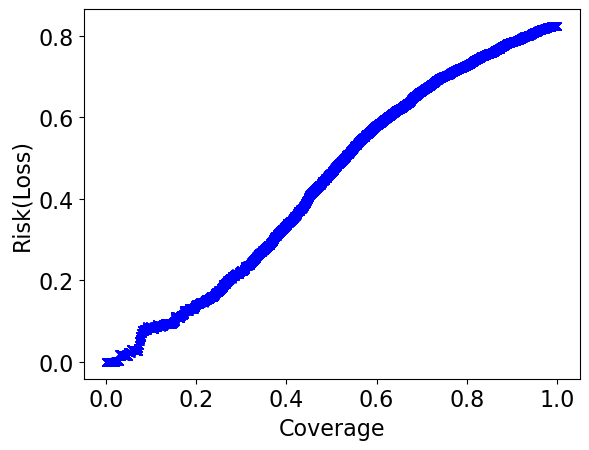

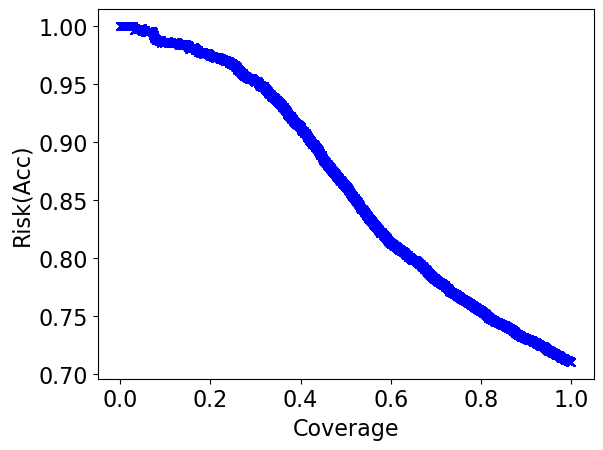

In [15]:
plt.figure(2)
# 根据输出方差排序样本后，前n个样本输出均值的平均loss
plt.plot((epochs + 1)/len(epochs), loss_list, 'b-', marker="x")  # bo:blue dot蓝点
plt.xlabel('Coverage', fontsize=16)
plt.ylabel('Risk(Loss)', fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()
plt.figure(3)
# 根据输出方差排序样本后，前n个样本输出均值的平均accuracy
plt.plot((epochs + 1)/len(epochs), acc_list, 'b-', marker="x")  # bo:blue dot蓝点
plt.xlabel('Coverage', fontsize=16)
plt.ylabel('Risk(Acc)', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()